In [8]:
from forecast import AnalisadorSerieTemporalCompleto
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv('09_Matriculas_BR.csv')


📊 DADOS FALTANTES DETECTADOS
Quantidade: 5 (10.20%)
Método de interpolação: linear
✓ Interpolação concluída

SÉRIE TEMPORAL: value
Período: 1970-01-01 00:00:00 até 2018-01-01 00:00:00
Frequência: YS
Total de observações: 49
Treino: 39 | Teste: 10


INICIANDO ANÁLISE COMPLETA DE SÉRIE TEMPORAL

1. ANÁLISE EXPLORATÓRIA DE DADOS

ESTATÍSTICAS DESCRITIVAS
--------------------------------------------------
Média...................................      3211628.51
Mediana.................................      1716263.00
Desvio Padrão...........................      2598914.71
Coef. Variação..........................           80.92
Mínimo..................................       430473.00
Máximo..................................      8741996.00
Amplitude...............................      8311523.00
Q1 (25%)................................      1436287.00
Q3 (75%)................................      4922587.00
IQR.....................................      3486300.00
Assimetria..............

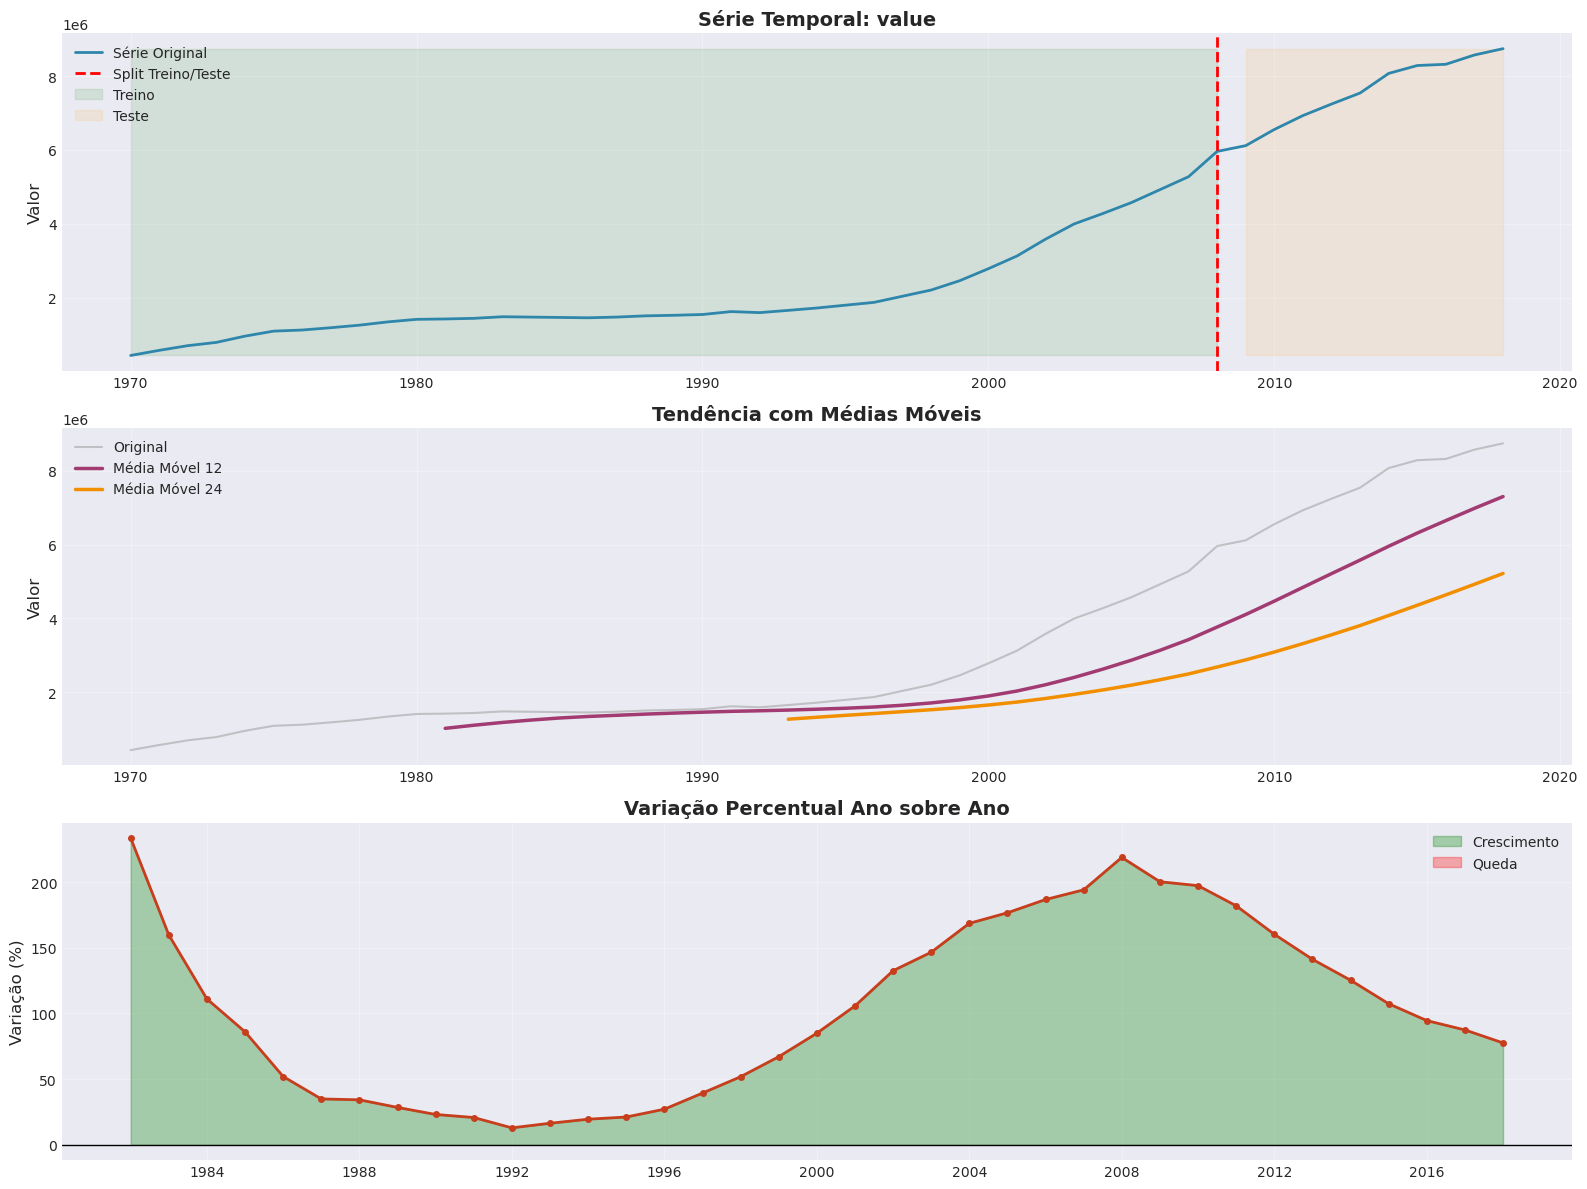

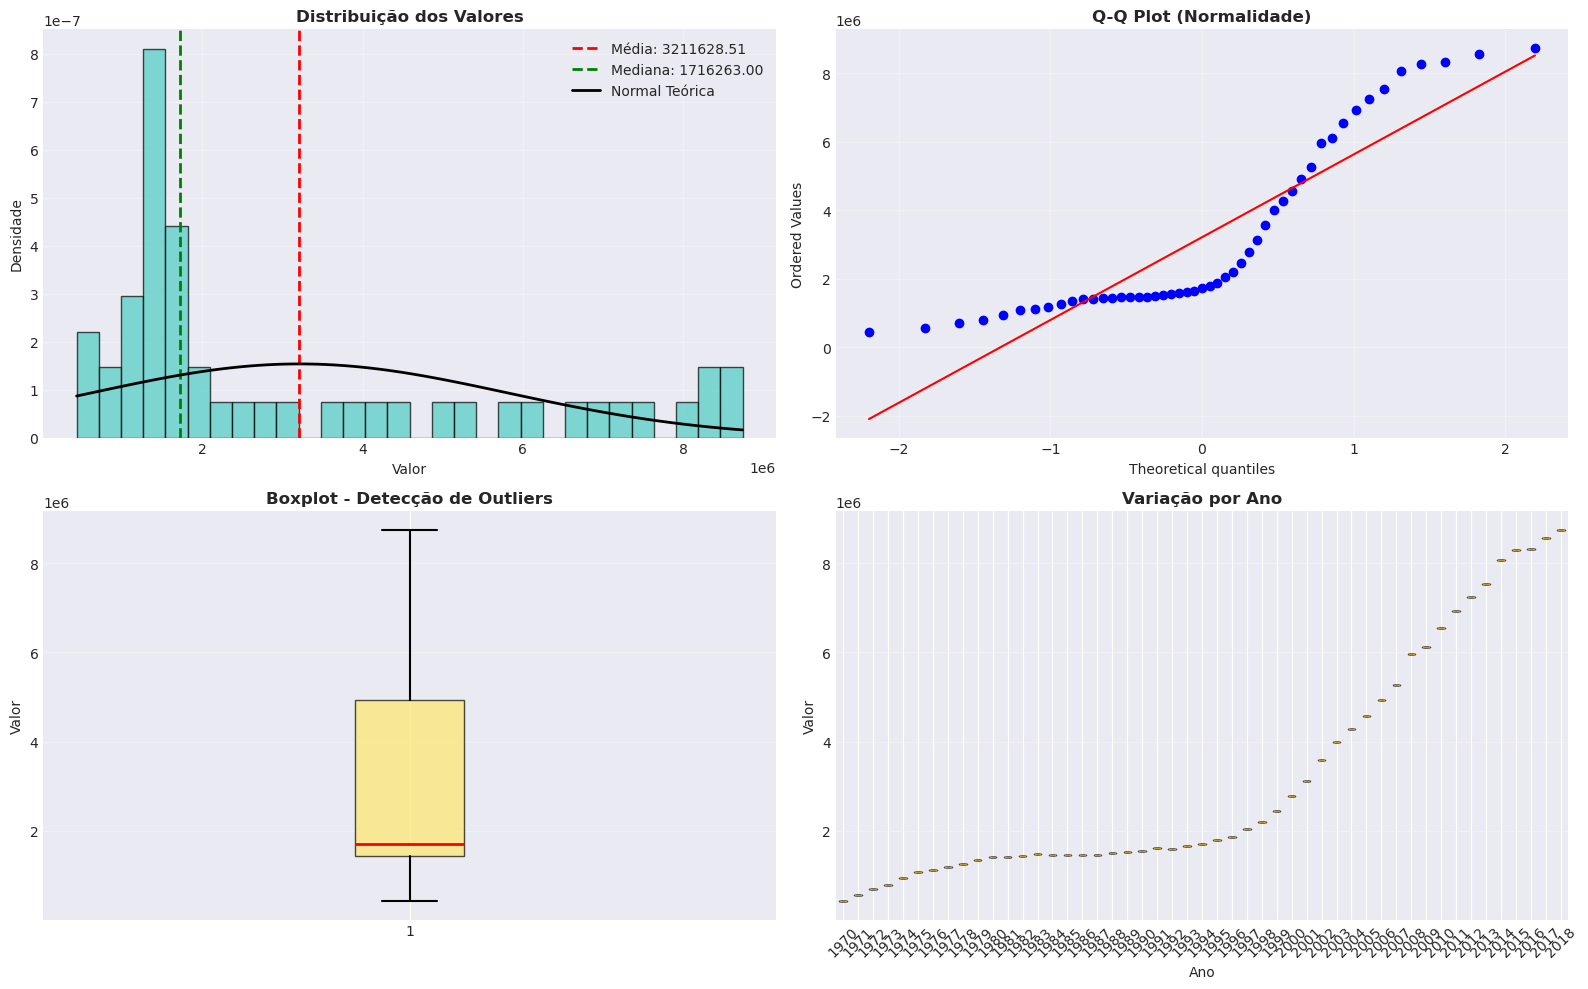

TESTE DE NORMALIDADE (Jarque-Bera)
Estatística: 8.1250
P-valor: 0.0172
Conclusão: Distribuição NÃO-NORMAL (α=0.05)

DETECÇÃO DE OUTLIERS
Método IQR: 0 outliers (0.00%)
Método Z-Score (>3): 0 outliers (0.00%)



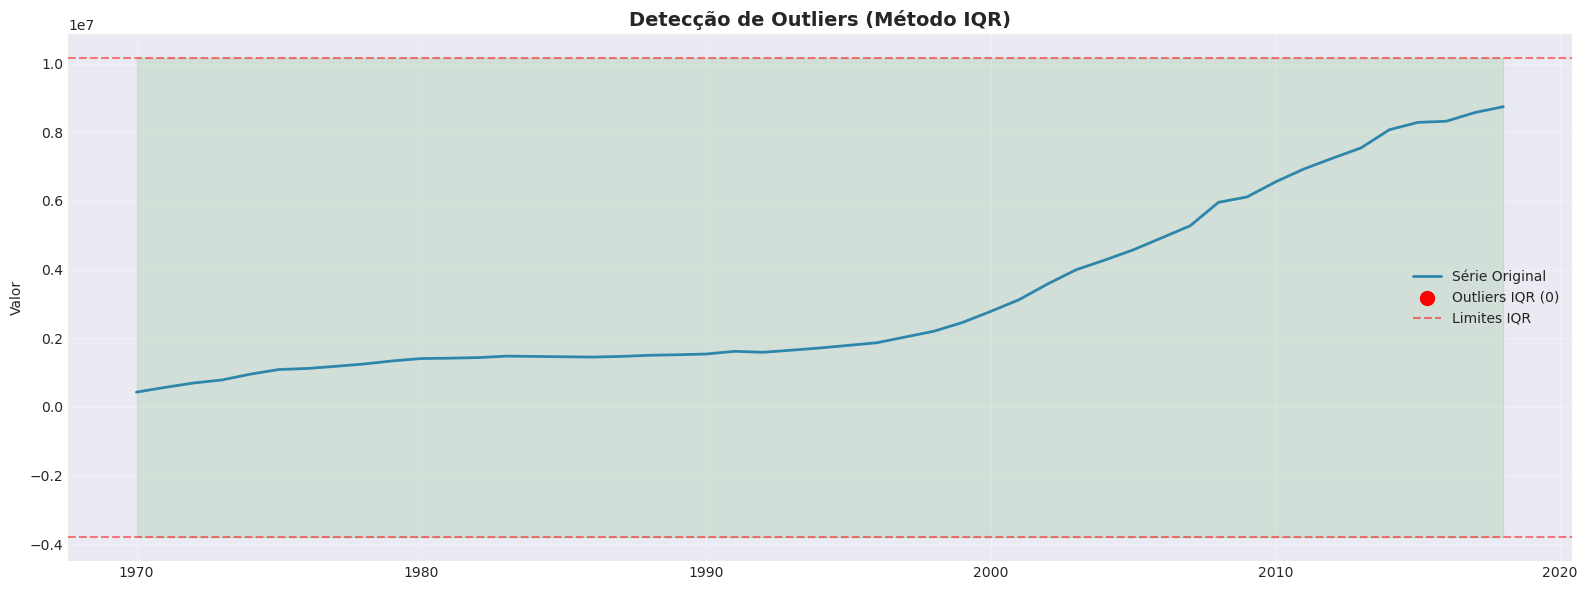


2. DECOMPOSIÇÃO SAZONAL



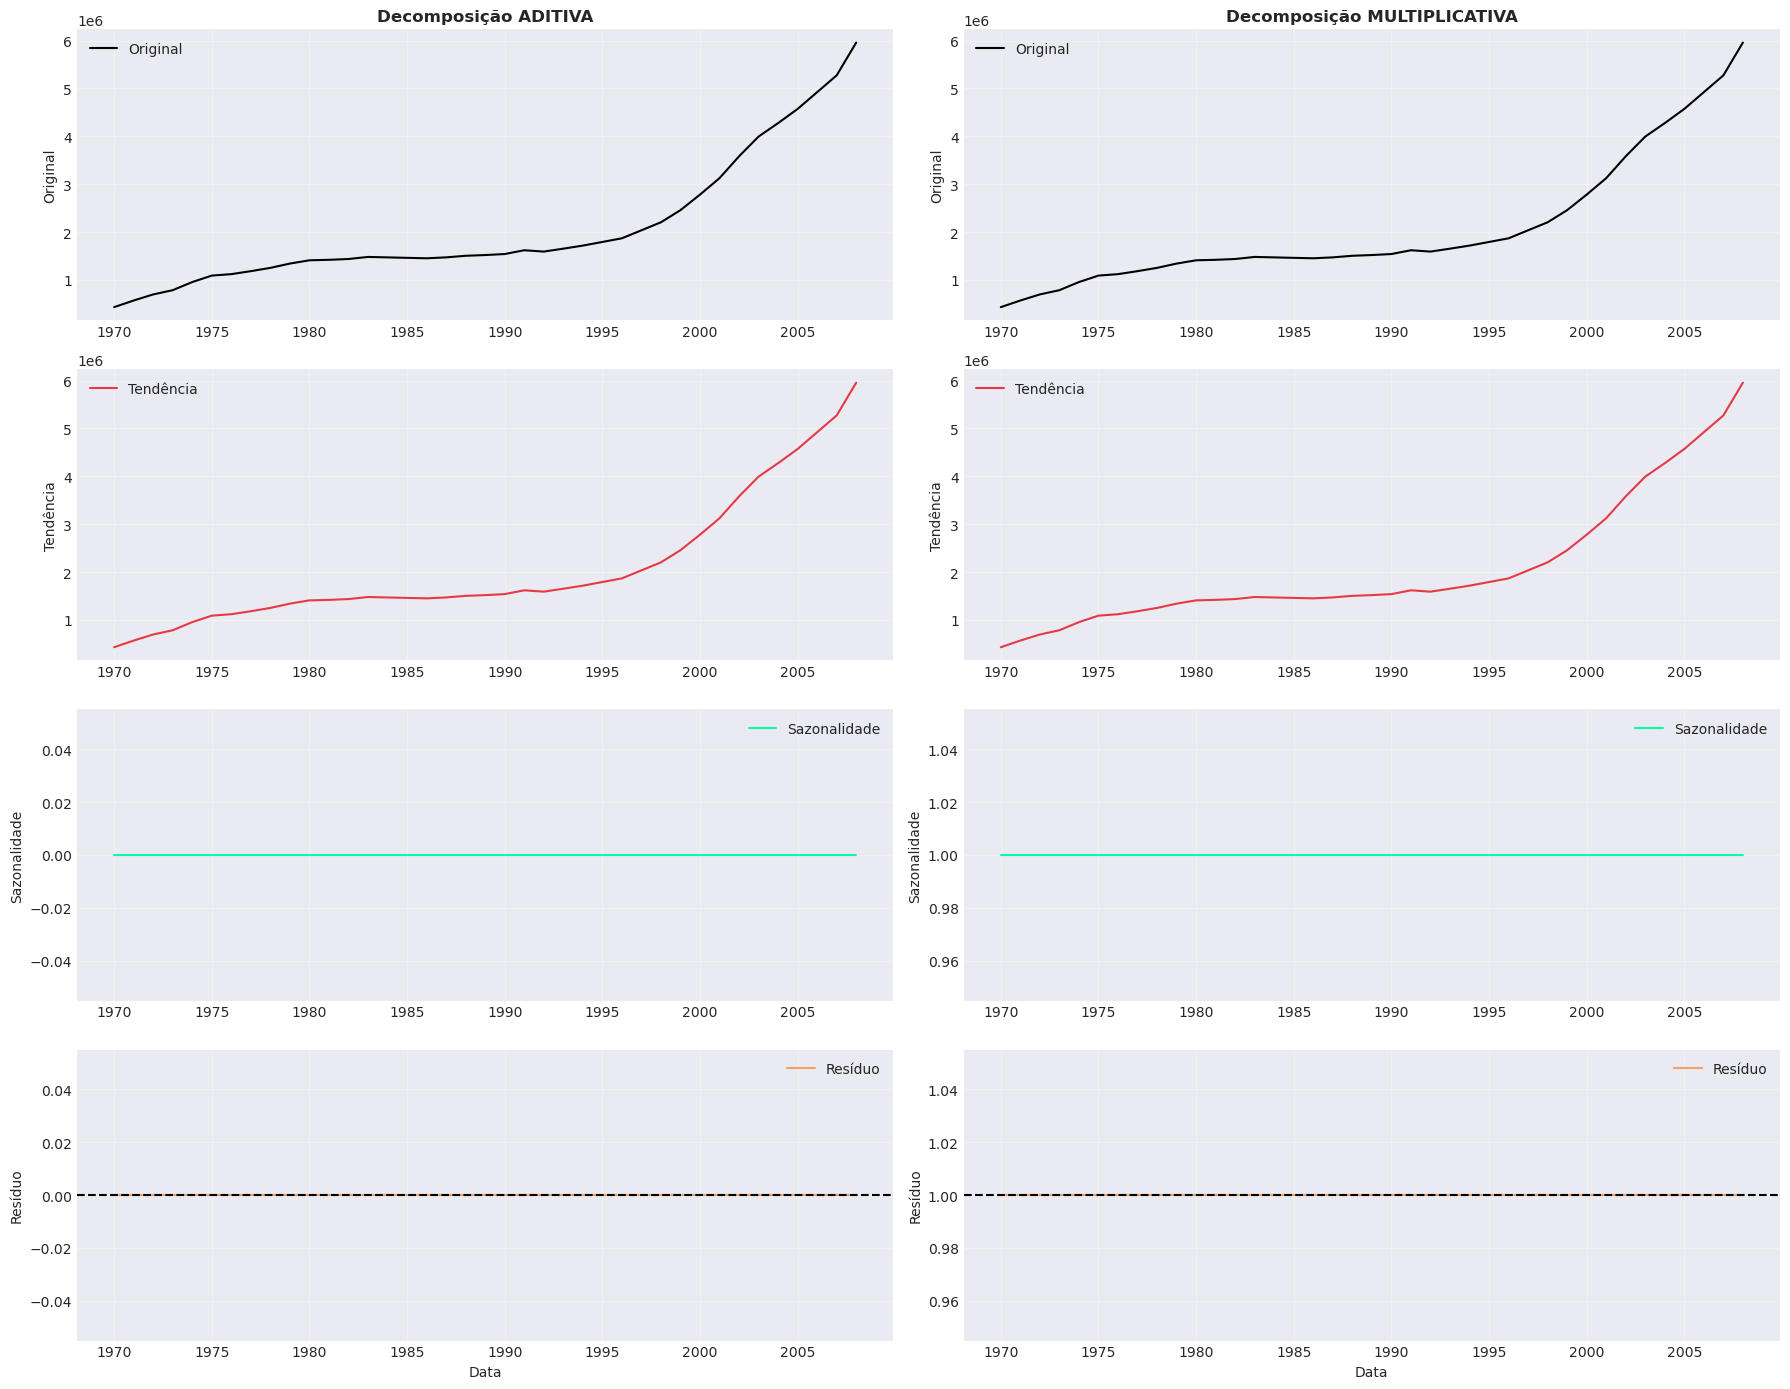

Não foi possível realizar decomposição clássica: float division by zero

Não foi possível realizar decomposição STL: period must be a positive integer >= 2


3. TESTES DE ESTACIONARIEDADE

TESTE ADF (Augmented Dickey-Fuller)
--------------------------------------------------
Estatística ADF: 2.894274
P-valor: 1.000000
Lags utilizados: 8
Número de observações: 30
Valores críticos:
  1%: -3.6699
  5%: -2.9641
  10%: -2.6212
Conclusão: Série é NÃO-ESTACIONÁRIA (não rejeita H0)

TESTE KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
--------------------------------------------------
Estatística KPSS: 0.194958
P-valor: 0.017891
Lags utilizados: 4
Valores críticos:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
Conclusão: Série é NÃO-ESTACIONÁRIA (rejeita H0)

INTERPRETAÇÃO COMBINADA:
Série é NÃO-ESTACIONÁRIA (ambos os testes concordam)



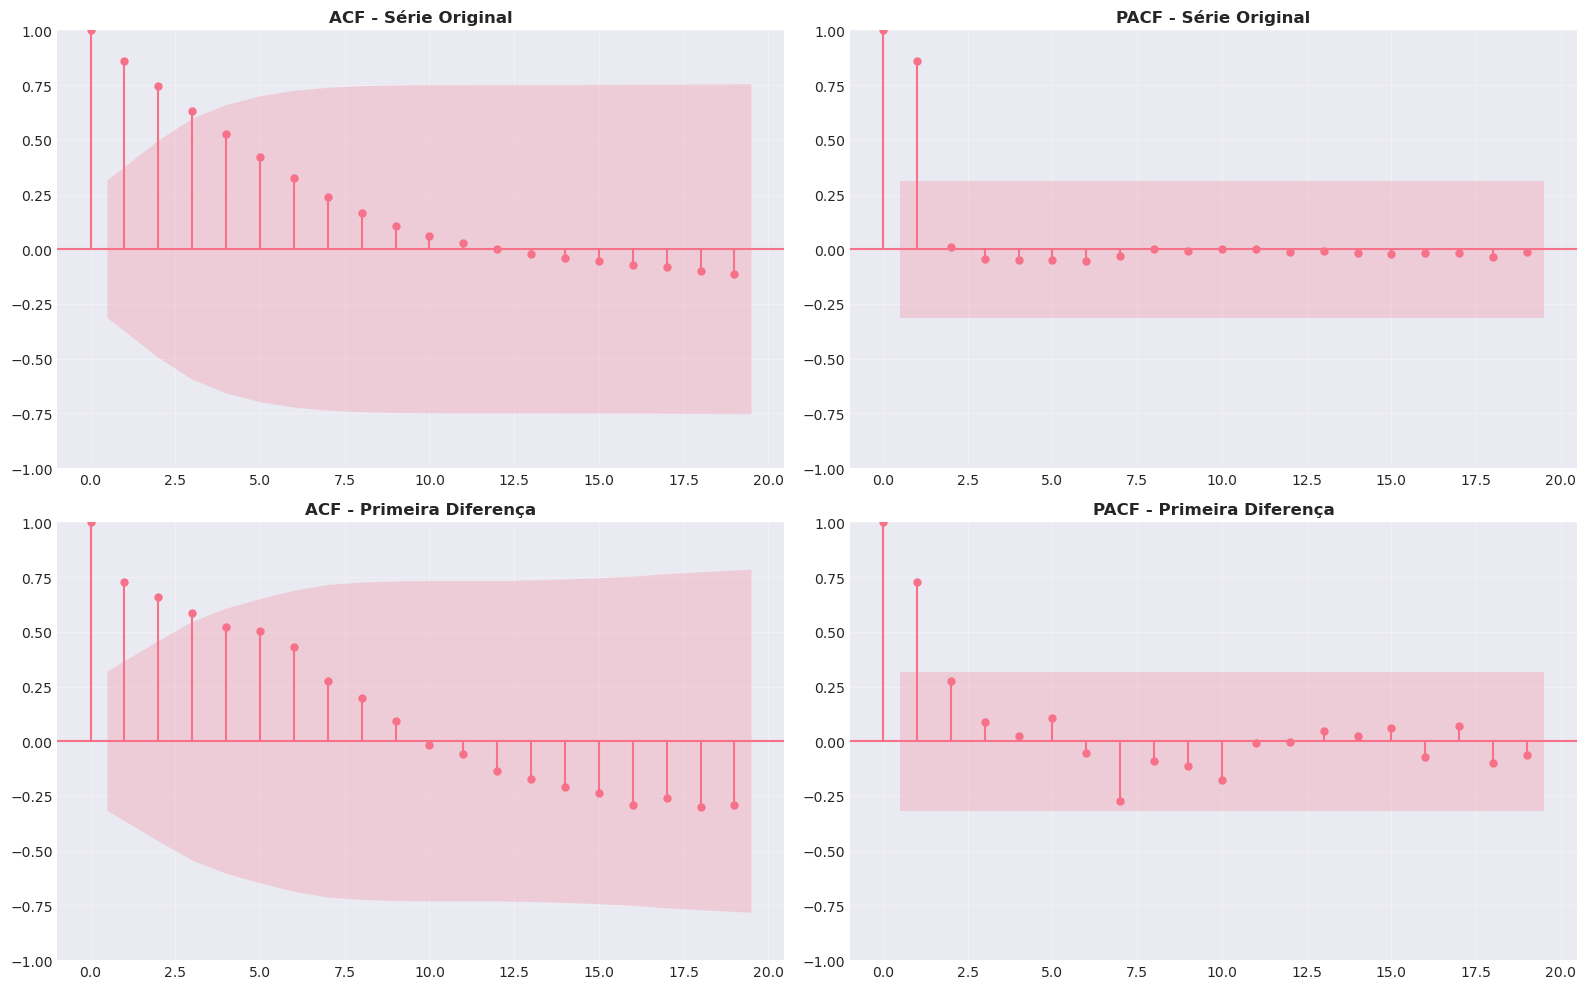


4. AJUSTE E COMPARAÇÃO DE MODELOS

RANDOM FOREST REGRESSOR
--------------------------------------------------
Random Forest treinado com sucesso
  Número de árvores: 200
  Features mais importantes:
    ano: 0.0697
    lag_2: 0.0674
    lag_10: 0.0666
    lag_3: 0.0621
    lag_8: 0.0612


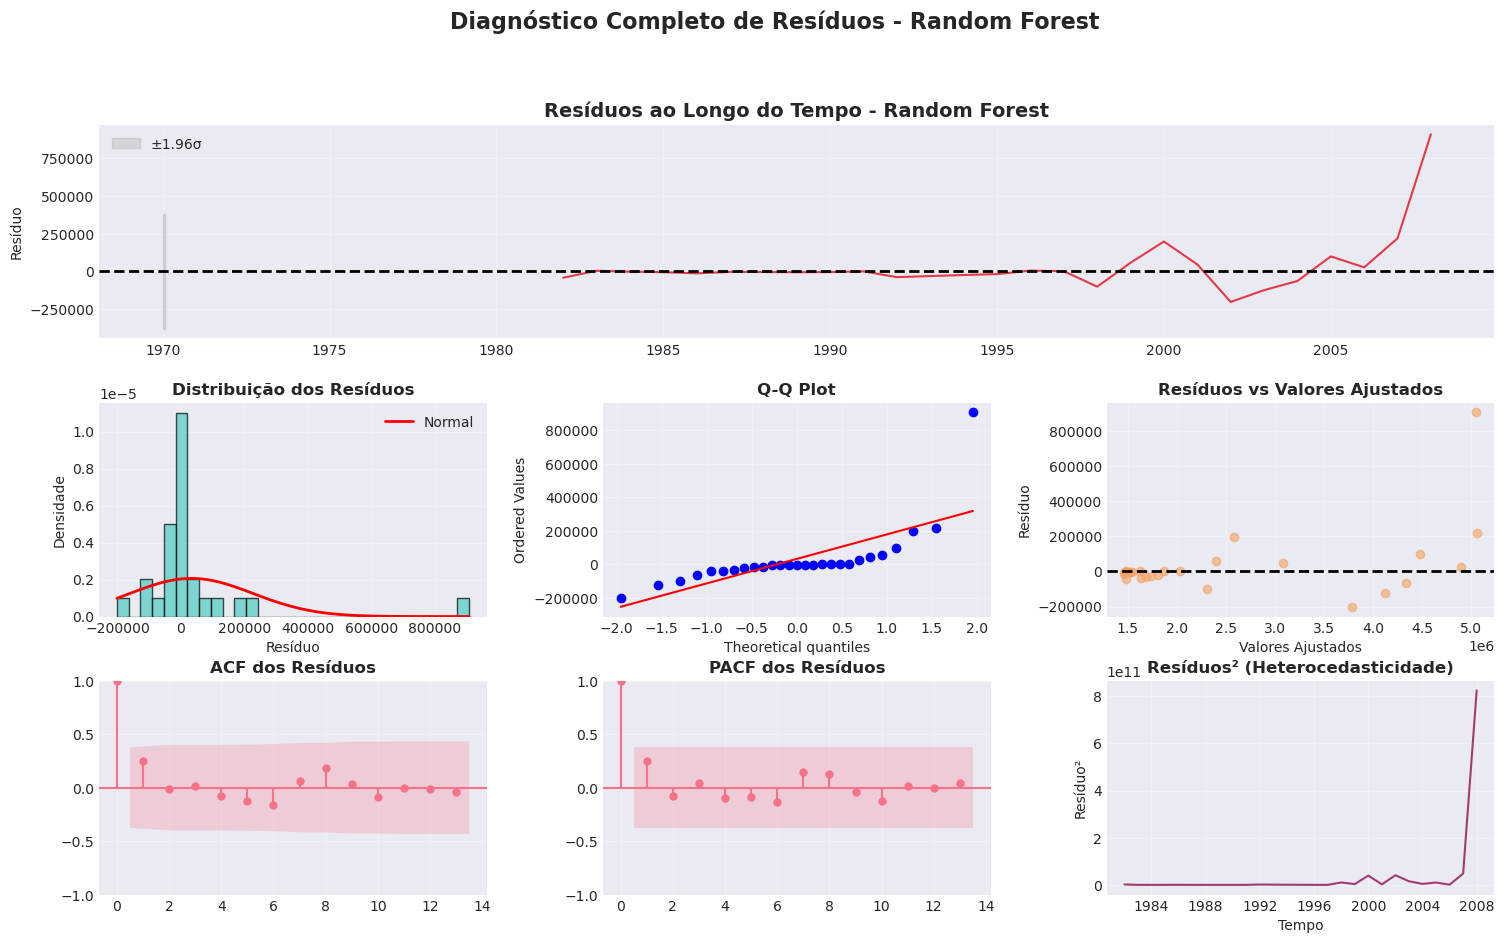


TESTES ESTATÍSTICOS DOS RESÍDUOS - Random Forest
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 273.2390 | P-valor: 0.0000
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.1770
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: 33094.542309 (deveria ser ~0)
  Desvio Padrão: 193516.9743
  Assimetria: 3.7769
  Curtose: 17.0759
------------------------------------------------------------

Random Forest ajustado com sucesso

HOLT-WINTERS (SUAVIZAÇÃO EXPONENCIAL)
--------------------------------------------------
✓ Melhor configuração: HW_add_mul
  AIC: 878.32
  BIC: 896.62


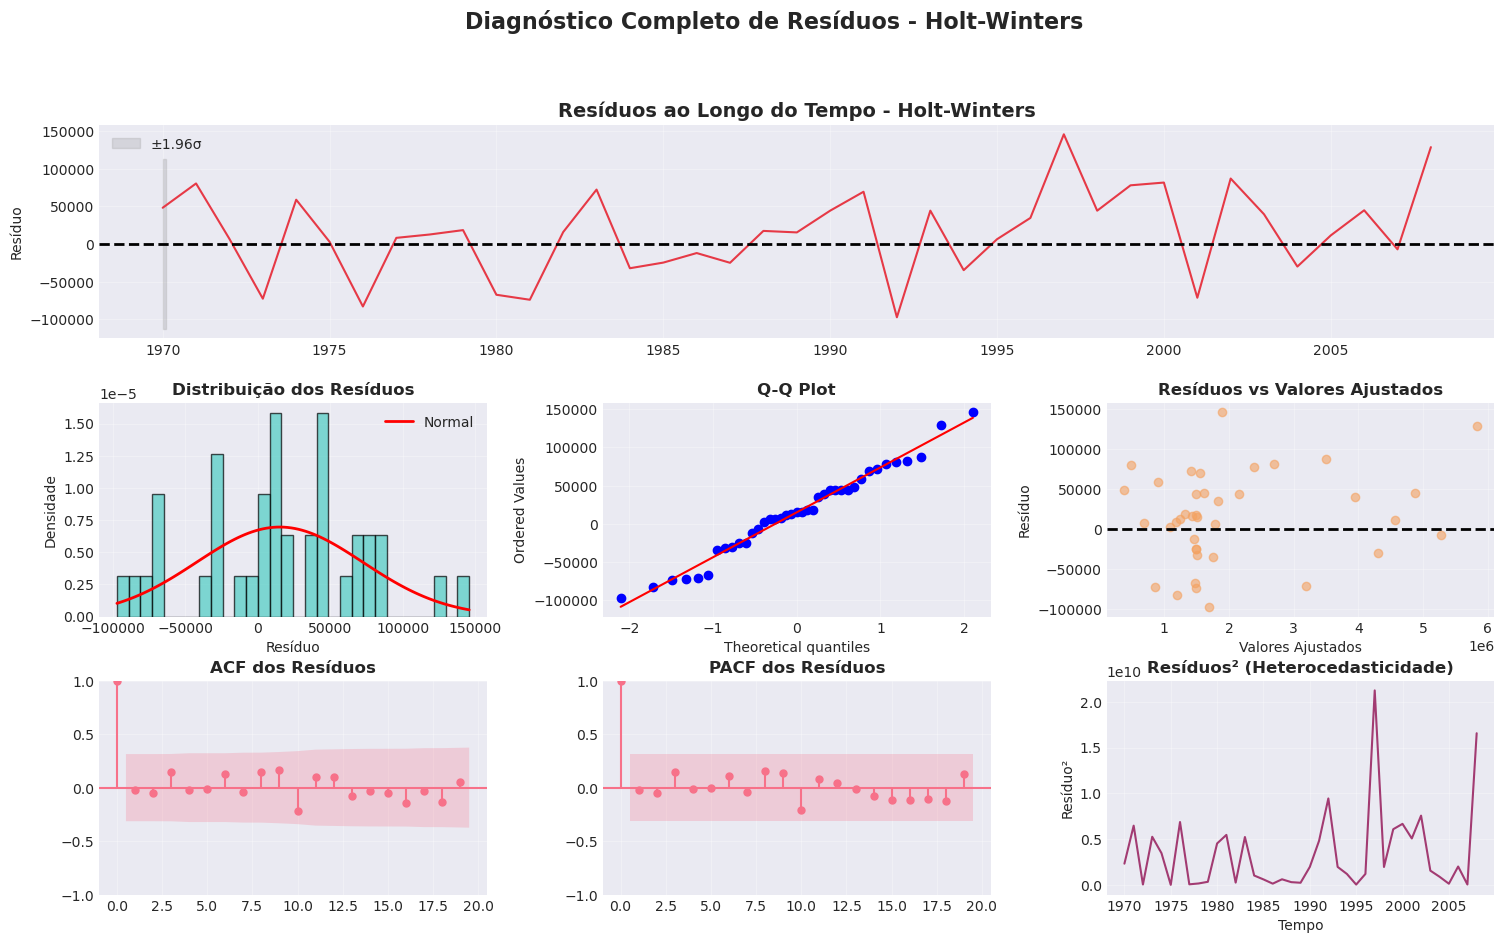


TESTES ESTATÍSTICOS DOS RESÍDUOS - Holt-Winters
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 0.2014 | P-valor: 0.9042
  Resíduos NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.7713
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: 15105.014223 (deveria ser ~0)
  Desvio Padrão: 57355.4315
  Assimetria: 0.0094
  Curtose: -0.2300
------------------------------------------------------------

✓ Holt-Winters ajustado com sucesso

SARIMA (AUTO-ARIMA)
--------------------------------------------------
Buscando melhor modelo SARIMA (pode levar alguns minutos)...
Melhor modelo: ARIMA(0, 2, 0) x (0, 0, 0, 0)[1]
  AIC: 940.08
  BIC: 941.69


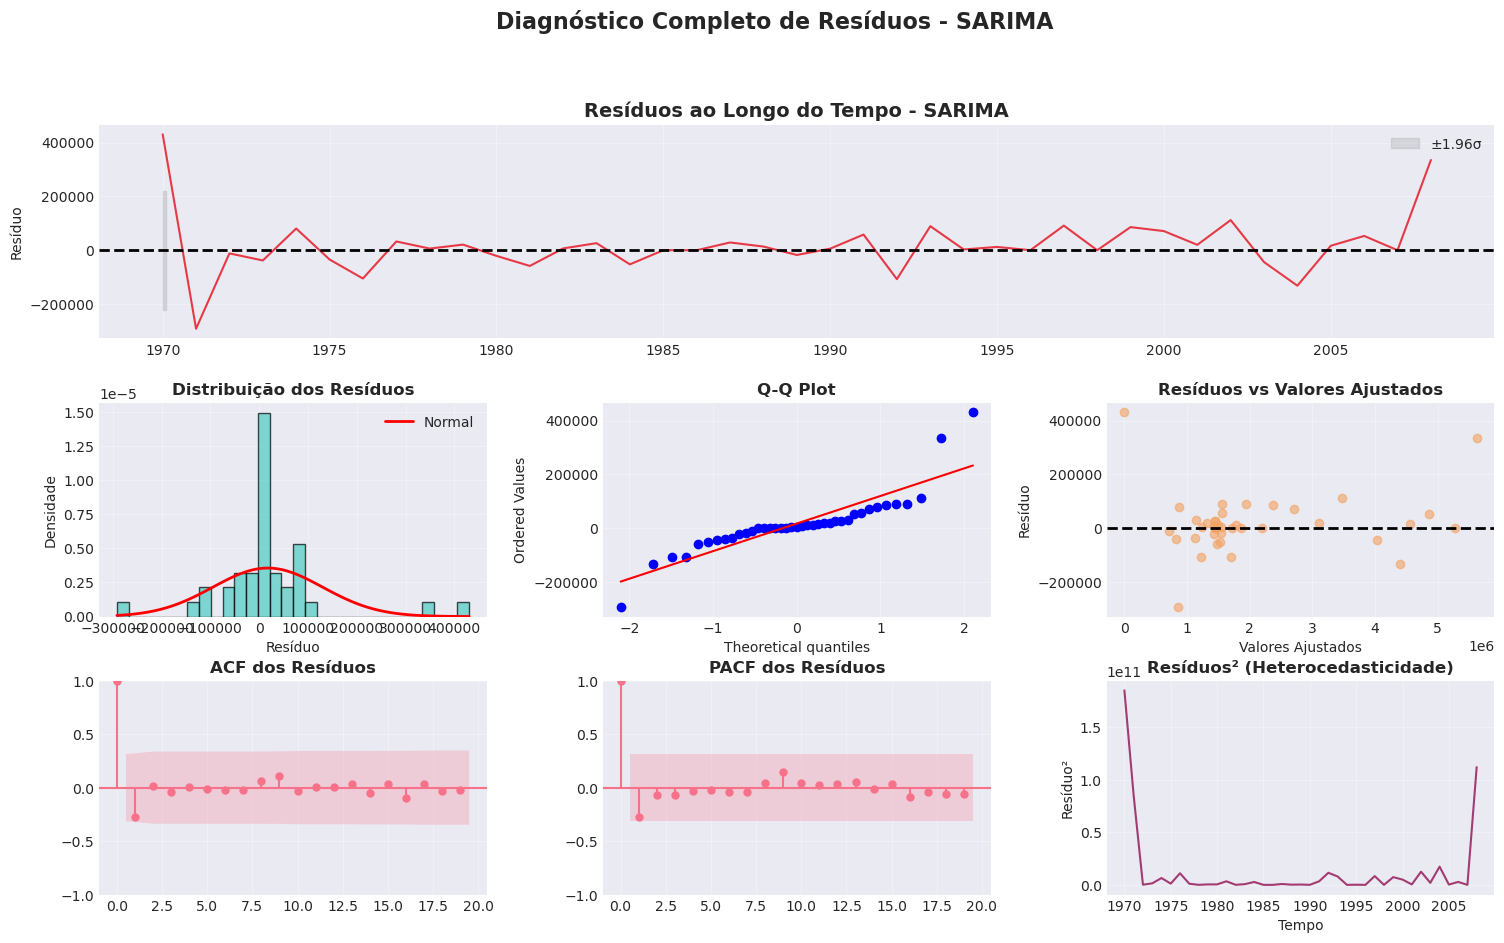

20:53:22 - cmdstanpy - INFO - Chain [1] start processing
20:53:23 - cmdstanpy - INFO - Chain [1] done processing



TESTES ESTATÍSTICOS DOS RESÍDUOS - SARIMA
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 57.3922 | P-valor: 0.0000
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0734
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: 17572.657762 (deveria ser ~0)
  Desvio Padrão: 112408.4027
  Assimetria: 1.3014
  Curtose: 6.3228
------------------------------------------------------------

SARIMA ajustado com sucesso

PROPHET
--------------------------------------------------


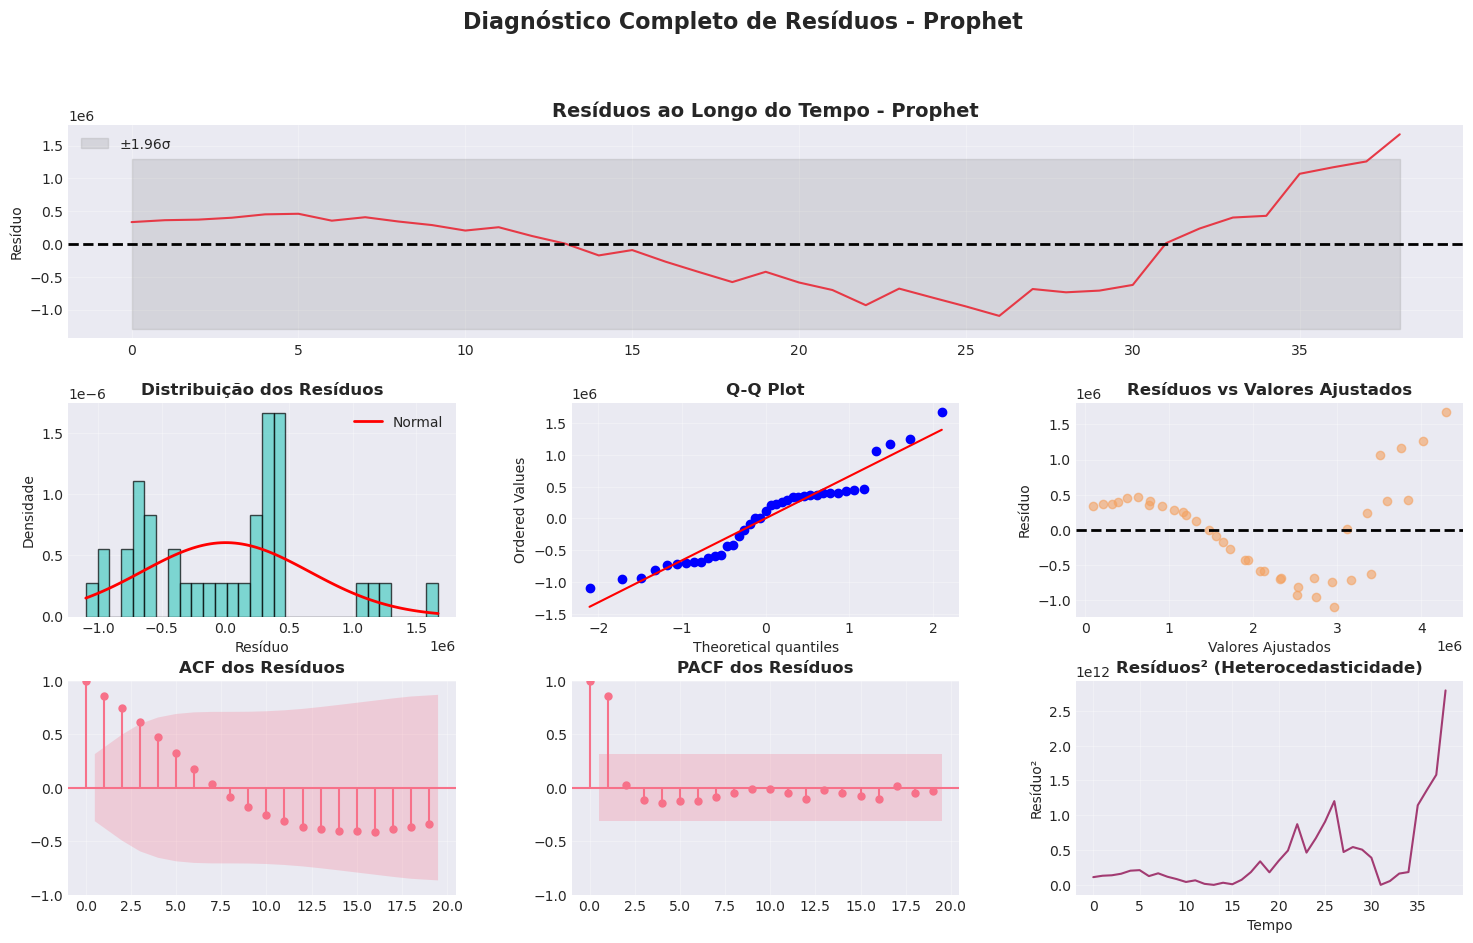


TESTES ESTATÍSTICOS DOS RESÍDUOS - Prophet
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 1.0424 | P-valor: 0.5938
  Resíduos NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0000
  ✗ COM autocorrelação

Estatísticas dos Resíduos:
  Média: 2414.486064 (deveria ser ~0)
  Desvio Padrão: 659428.2136
  Assimetria: 0.3858
  Curtose: -0.1741
------------------------------------------------------------



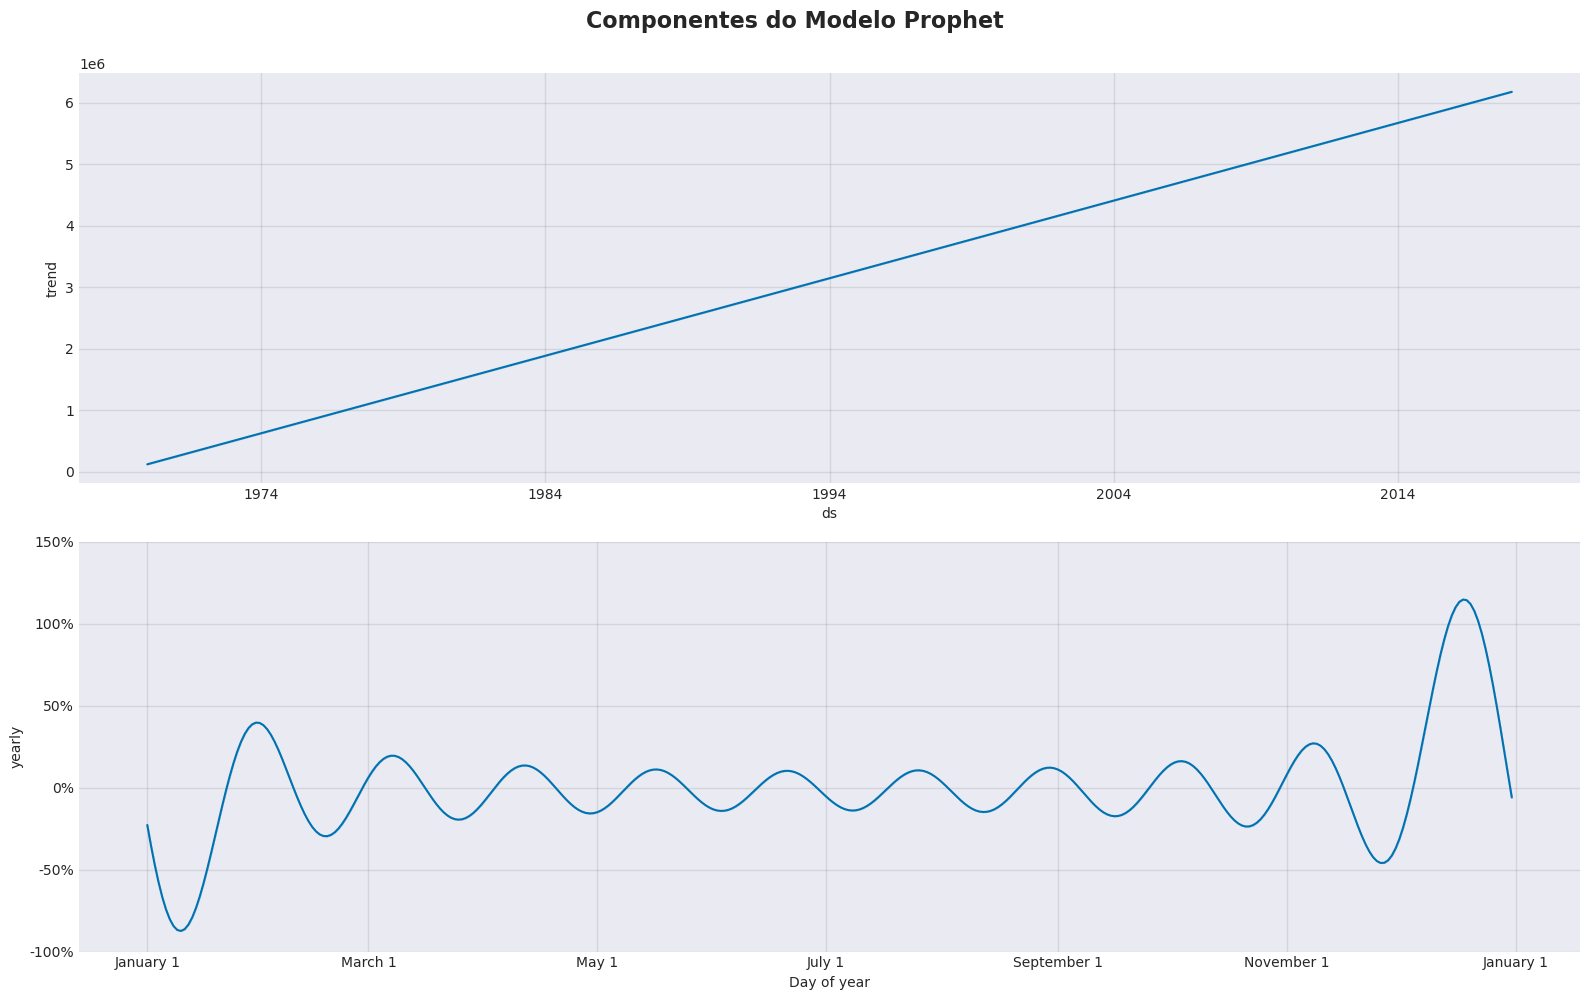

Prophet ajustado com sucesso


5. COMPARAÇÃO VISUAL DOS MODELOS



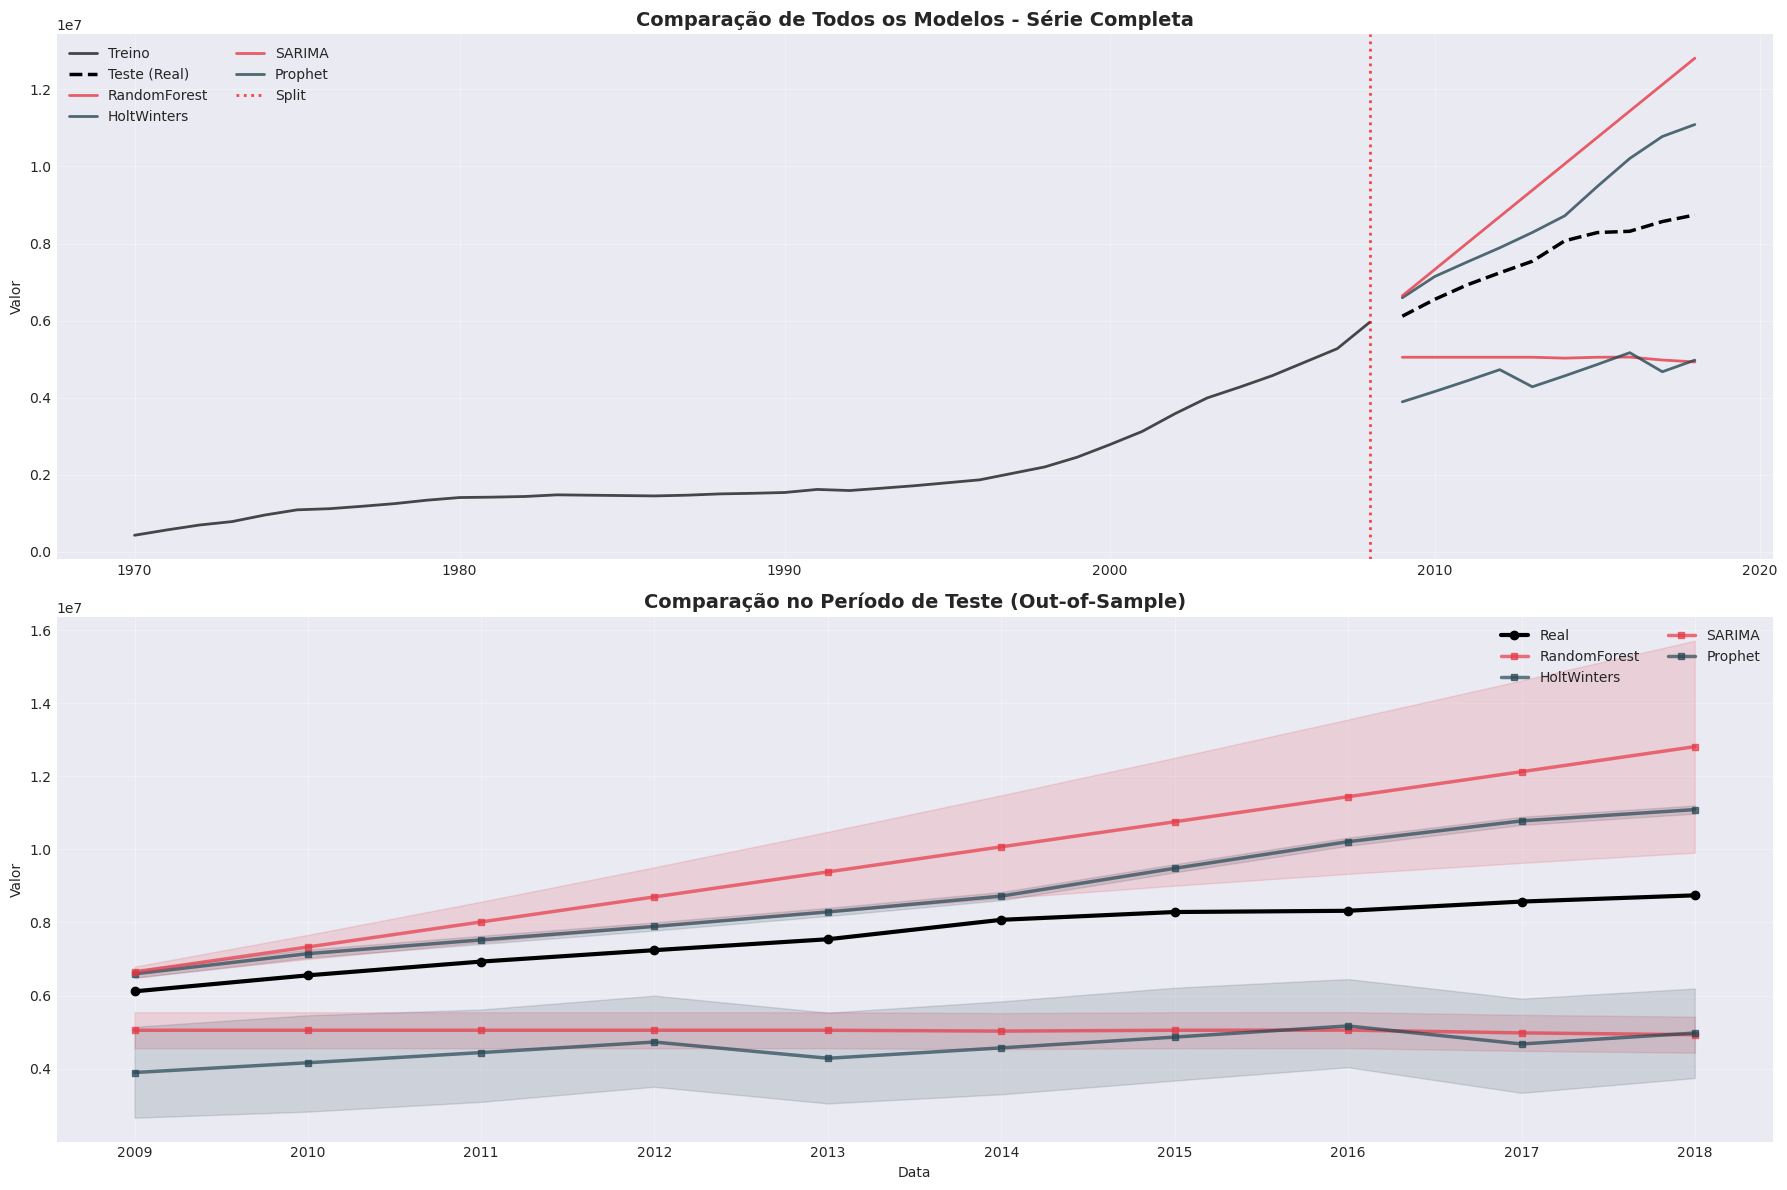


6. RANKING E MÉTRICAS DE PERFORMANCE

TABELA DE MÉTRICAS (ordenada por melhor performance)
                       MAE          RMSE     MAPE    SMAPE       R²  Rank_Médio
HoltWinters   1.135172e+06  1.331164e+06  14.2118  13.0511  -1.4183         1.0
SARIMA        2.090072e+06  2.378985e+06  26.0781  22.5699  -6.7237         2.0
RandomForest  2.608163e+06  2.752955e+06  33.2326  40.4254  -9.3429         3.0
Prophet       3.061745e+06  3.115983e+06  39.7839  49.7967 -12.2505         4.0

MELHOR MODELO: HoltWinters
   MAE: 1135171.7470
   RMSE: 1331164.0133
   MAPE: 14.21%
   R²: -1.4183


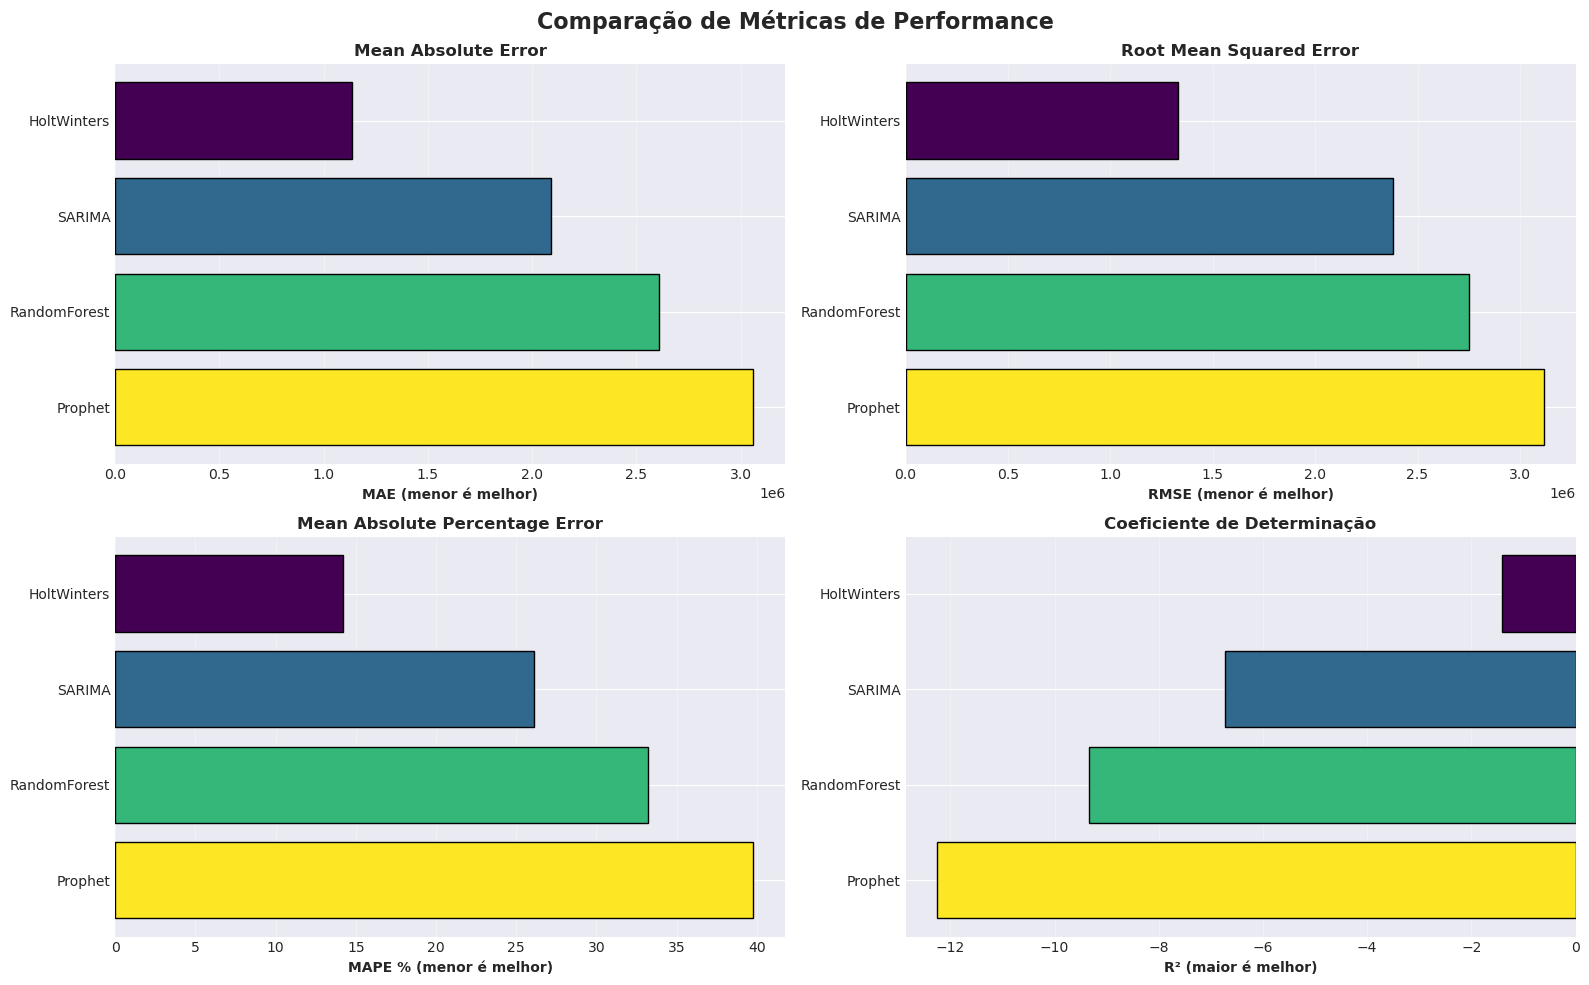


PREVISÃO FUTURA - 1 PERÍODOS À FRENTE

Gerando previsões com Random Forest...
✓ Random Forest concluído
Gerando previsões com Holt-Winters...
✓ Holt-Winters concluído
Gerando previsões com SARIMA...
✓ SARIMA concluído
Gerando previsões com Prophet...
✓ Prophet concluído


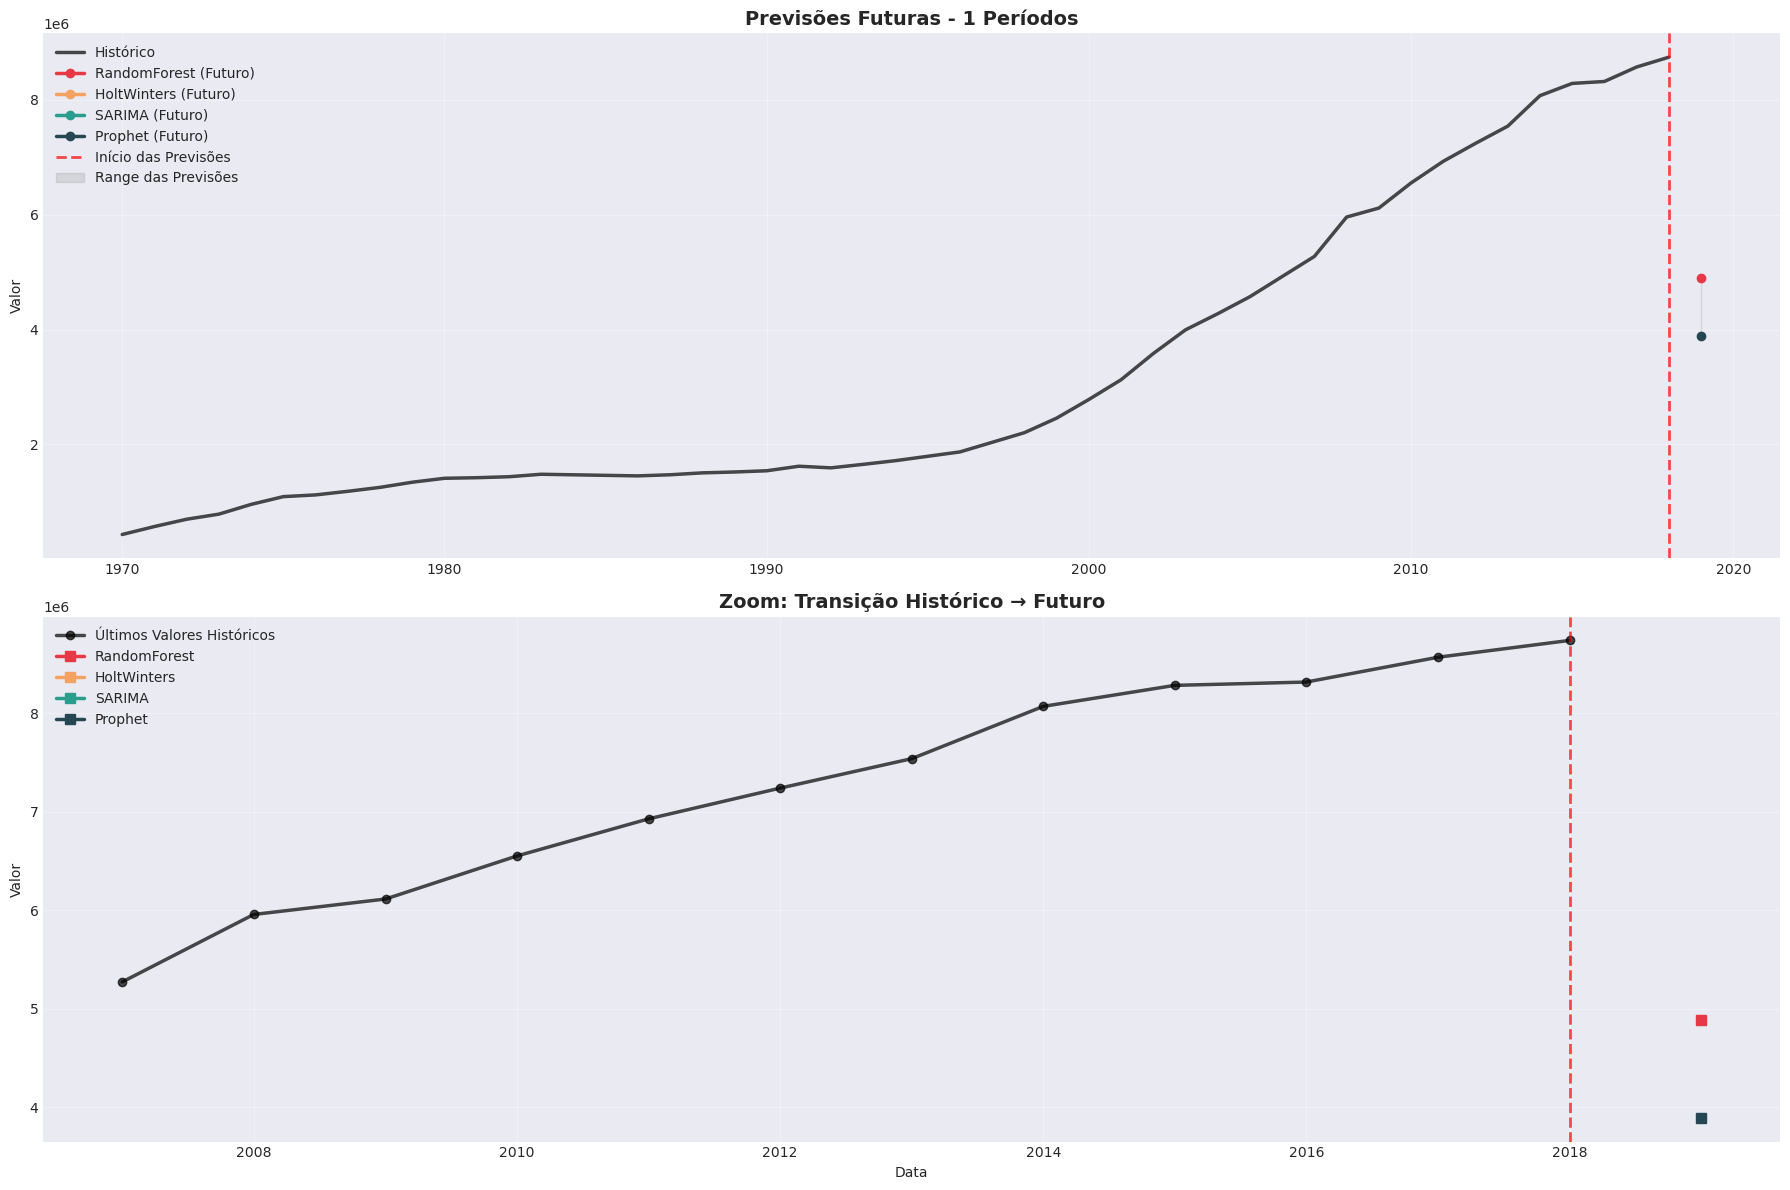


RESUMO DAS PREVISÕES FUTURAS

            RandomForest  HoltWinters  SARIMA     Prophet
2019-01-01    4889468.63          NaN     NaN  3893417.81

Estatísticas por período:
       RandomForest  HoltWinters  SARIMA     Prophet
count          1.00          0.0     0.0        1.00
mean     4889468.63          NaN     NaN  3893417.81
std             NaN          NaN     NaN         NaN
min      4889468.63          NaN     NaN  3893417.81
25%      4889468.63          NaN     NaN  3893417.81
50%      4889468.63          NaN     NaN  3893417.81
75%      4889468.63          NaN     NaN  3893417.81
max      4889468.63          NaN     NaN  3893417.81


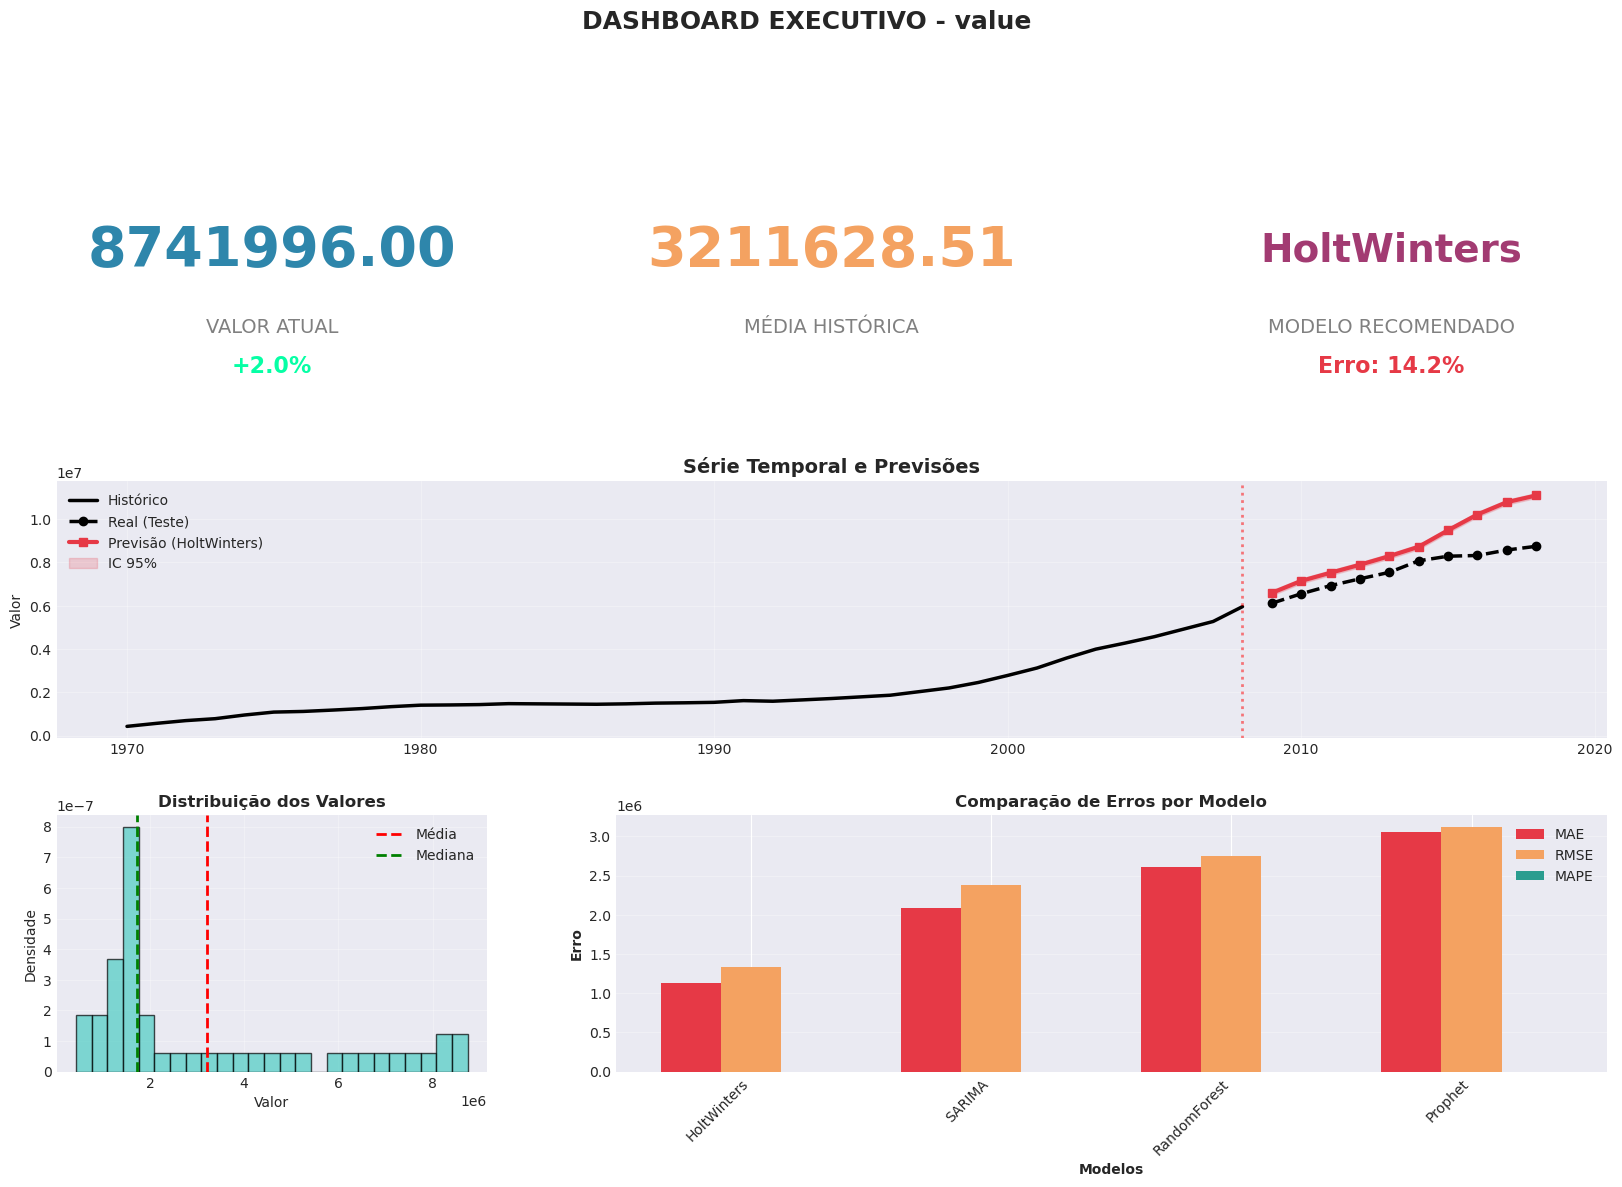


7. RELATÓRIO EXECUTIVO

RESUMO DA ANÁLISE
--------------------------------------------------------------------------------
Variável Analisada: value
Período: 1970-01-01 até 2018-01-01
Total de Observações: 49
Frequência: YS

Tendência Geral: CRESCIMENTO de 1930.8%
Valor Médio: 3211628.51
Volatilidade (CV): 80.9%

🏆 MODELO RECOMENDADO: HoltWinters
   Precisão: 85.8% (Erro médio: 14.2%)
   Interpretação: O modelo erra em média 14.2% do valor real

PRÓXIMA PREVISÃO: 6593639.28
   Intervalo de Confiança 95%: [6481222.63, 6706055.92]
   Cenário Pessimista: 6481222.63
   Cenário Mais Provável: 6593639.28
   Cenário Otimista: 6706055.92

ANÁLISE COMPLETA FINALIZADA



In [10]:
analisador = AnalisadorSerieTemporalCompleto(
    df=df,
    data_col='date',
    valor_col='value',
    frequencia='YS', 
    test_size=0.2
)
previsoes = analisador.analise_completa(periodos_futuros=1)